# Acquisition notebook

This notebook is split between:
- **run cells** here
- reusable helpers in the `utils/` Python files next to the notebook

The goal is to keep this notebook readable and focused on experiments.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager
from datetime import datetime
from pathlib import Path

In [3]:
from utils.oc_linux import OC3

from utils.scpi import scpi_write, scpi_readline
from utils.tektronix import acquire_displayed_channels
from utils.temperature import (
    generate_temperature_list,
    wait_for_stable_temperature,
    wait_for_user_popup,
    finalize_oc3,
)
from utils.pm100a import (
    find_pm100a,
    pm100a_get_sensor_info,
    pm100a_read_value,
    pm100a_set_average_count,
    pm100a_record_timeseries,
)

In [73]:
DATA_DIR = "data/data_temp_SHG"
os.makedirs(DATA_DIR, exist_ok=True)

In [5]:
wavelength = 780e-6 # wavelength in microns!

# Knife-edge

Knife-edge methods for waist measurement and gaussian beam fit.

In [1]:
from scipy.special import erf
from scipy.optimize import curve_fit

In [52]:
# Trous spacing
hole = 25.0 # mm

## Displacement VS Intensity

Displacement of the knife over length to find the waist at a given position.

In [53]:
L = 0 * hole # mm from razor to power meter

In [54]:
# intensity = np.array([39.0, 39.0, 37.0, 34.0, 29.5, 23.8, 15.5, 8.0, 3.5, 1.50])
# position = np.array([5.5, 5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0])

position  = np.array([7.5, 7.25, 7.0, 6.75, 6.5, 6.25, 6.0, 5.75, 5.5, 5.25, 5.0, 4.75, 4.5, 4.25, 4.0, 3.75, 3.6, 3.5, 3.4, 3.3, 3.25, 3.1, 3.0, 2.75, 2.6, 2.5, 2.25, 2.0, 1.75, 1.5, 1.25, 1.0]) -1
print(position)
intensity = np.array([39.3, 39.0, 38.1, 38.2, 37.5, 37.5, 37.5,  37.4, 37, 34.3, 31.3, 30.5, 26.4, 24.7, 20.8, 18.1, 16.7, 14.7, 12.8, 12.2, 10.4, 8.8, 5.7, 4.2, 3.8, 3.3, 2.5, 1.7, 1.0, 0.6, 0.3, 0.1])

print(position.shape, intensity.shape)

[6.5  6.25 6.   5.75 5.5  5.25 5.   4.75 4.5  4.25 4.   3.75 3.5  3.25
 3.   2.75 2.6  2.5  2.4  2.3  2.25 2.1  2.   1.75 1.6  1.5  1.25 1.
 0.75 0.5  0.25 0.  ]
(32,) (32,)


In [55]:
intensity /= intensity.max()
print(intensity)
displacement = position[0] - position  # convert to displacement from edge (mm)
print(displacement)

[1.         0.99236641 0.96946565 0.97201018 0.95419847 0.95419847
 0.95419847 0.95165394 0.94147583 0.87277354 0.79643766 0.77608142
 0.67175573 0.62849873 0.52926209 0.4605598  0.42493639 0.3740458
 0.32569975 0.31043257 0.26463104 0.22391858 0.14503817 0.10687023
 0.09669211 0.08396947 0.06361323 0.043257   0.02544529 0.01526718
 0.00763359 0.00254453]
[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75 3.9  4.   4.1  4.2  4.25 4.4  4.5  4.75 4.9  5.   5.25 5.5
 5.75 6.   6.25 6.5 ]


In [56]:
def knife_edge(d, d0, w):
    """ Knife-edge function model for Gaussian beam profile.

    Parameters:
    d : array-like
        Displacement of the razor edge (mm).
    d0 : float
        Center position of the beam (mm).
    w : float
        Beam waist (1/e^2 radius) (mm).

    Returns:
    array-like
        Normalized intensity as a function of displacement.
    """
    return 0.5 * (1 - erf(np.sqrt(2) * (d - d0) / w))

In [57]:
p0 = [np.median(displacement), 0.05]  # initial guess: center, beam radius
params, cov = curve_fit(knife_edge, displacement, intensity, p0=p0)
d0_fit, w_fit = params
w_err = np.sqrt(w_fit)

In [58]:
print("\nFitted parameters:")
# print("Coefficient a0 =", a0)
print(f"Beam center in mm d0 = {d0_fit:.3f}")
print(f"Beam waist w in mm = {w_fit:.3f} ± {w_err:.3f} (same units as d)")


Fitted parameters:
Beam center in mm d0 = 3.572
Beam waist w in mm = 2.221 ± 1.490 (same units as d)


In [59]:
def waist_from_propagated(wz, z, wavelength):
    """
    Solve w(z)^2 = w0^2 + (lam*z/(pi*w0))^2
    Returns the physical (small-waist) solution
    """
    from scipy.optimize import fsolve

    def equation(w0):
        return wz**2 - w0**2 * (1 + (wavelength * z / (w0**2 * np.pi))**2)

    w0_initial_guess = wz / 2
    w0_solution, = fsolve(equation, w0_initial_guess)
    return w0_solution

In [ ]:
print("Beam waist at razor position w0 in mm =", waist_from_propagated(w_fit, L, wavelength))

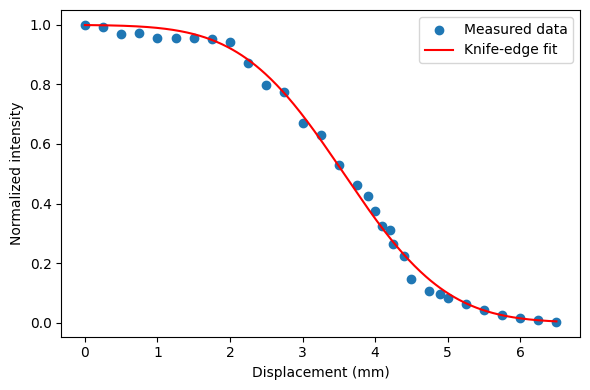

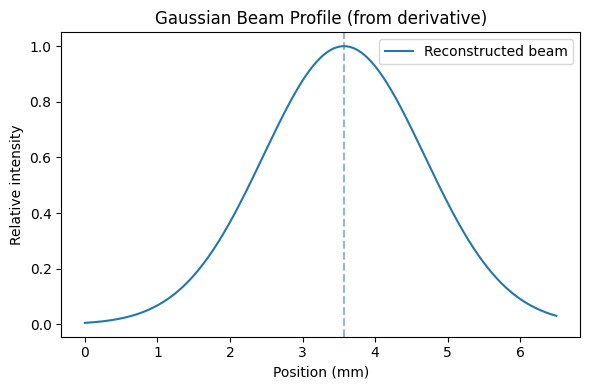

In [60]:
    # -----------------------------
# Reconstruct beam profile
# -----------------------------
x_profile = np.linspace(min(displacement), max(displacement), 500)
# derivative of knife-edge signal
# gaussian_profile = (a0 * np.sqrt(2/np.pi) / w_fit) * \
#     np.exp(-2 * (x_profile - d0_fit)**2 / w_fit**2)

gaussian_profile = (np.sqrt(2/np.pi) / w_fit) * \
    np.exp(-2 * (x_profile - d0_fit)**2 / w_fit**2)

# normalize
gaussian_profile /= np.max(gaussian_profile)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(displacement, intensity, label="Measured data")
plt.plot(x_profile, knife_edge(x_profile, *params),
         color="red", label="Knife-edge fit")
plt.xlabel("Displacement (mm)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x_profile, gaussian_profile, label="Reconstructed beam")
plt.axvline(d0_fit, linestyle="--", alpha=0.5)
plt.xlabel("Position (mm)")
plt.ylabel("Relative intensity")
plt.title("Gaussian Beam Profile (from derivative)")
plt.legend()
plt.tight_layout()
plt.show()

## 80/20 Method

Record difference of position between 20% and 80% of the light, find the waist using $w = \Delta x / 0.842$

Acquisition cell:
- prompts the user with the total power in mW
- display the corresponding 80%/20% power to use
- ask for the $x_{80}$, $x_{20}$ for hole 0, then $x_{20}$, $x_{80}$ for hole 1, and so on
- asks if the user wants to skip the prompted hole before.

In [30]:
# --- CONFIG ---
DATA_DIR = Path("./data/knife_edge")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- TOTAL POWER ---
P_tot = float(input("Enter total power (mW): "))
P80 = 0.8 * P_tot
P20 = 0.2 * P_tot

print(f"\nTarget powers:")
print(f"  80% = {P80:.3f} mW")
print(f"  20% = {P20:.3f} mW\n")

# --- NUMBER OF POINTS ---
n_points = int(input("How many holes (points) do you want to acquire? "))

# --- STORAGE ---
holes = []
x80_list = []
x20_list = []

print("\n--- Acquisition start ---")
print("Hole 0: x80 → x20")
print("Then alternate: x20 → x80\n")

i = 0
while i < n_points:
    print(f"\nHole {i}/{n_points-1}")

    # Ask if redo the previous hole
    if i > 0:
        redo = input("Redo previous hole? (y/n): ").strip().lower()
        if redo == "y":
            # remove the last entry
            holes.pop()
            x80_list.pop()
            x20_list.pop()
            i -= 1
            print("Previous hole removed. Re-entering...")
            continue

    try:
        if i % 2 == 0:
            # even index: x80 then x20
            x80 = float(input(f"Enter x80 (target {P80:.3f} mW): "))
            x20 = float(input(f"Enter x20 (target {P20:.3f} mW): "))
        else:
            # odd index: x20 then x80
            x20 = float(input(f"Enter x20 (target {P20:.3f} mW): "))
            x80 = float(input(f"Enter x80 (target {P80:.3f} mW): "))

        holes.append(i)
        x80_list.append(x80)
        x20_list.append(x20)

        i += 1

    except ValueError:
        print("Invalid input, please enter numeric values.")

# --- CREATE DATAFRAME ---
df = pd.DataFrame({
    "Trous": holes,
    "x80": x80_list,
    "x20": x20_list
})

# --- SAVE ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filepath = DATA_DIR / f"knife_edge_{timestamp}.csv"

df.to_csv(filepath, index=False)

print("\nSaved to:", filepath)
df

KeyboardInterrupt: Interrupted by user

In [61]:
DATA_DIR = Path("./data/knife_edge")
use_run = False
if use_run:
    data_file = filepath # select the file from the acquisition cell
else:
    data_file = DATA_DIR / "2026_04_24_f500.csv" # manually select the file

data = pd.read_csv(data_file)

In [62]:
# CSV is expected to have columns "Trous", "80%", "20%" (distance to obtain 80% and 20% of intensity)
# d = data["Trous"].astype(float).to_numpy() * hole  # in mm
# x80 = data["80%"].astype(float).to_numpy()
# x20 = data["20%"].astype(float).to_numpy()

x80 = (
    data["80%"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
    .to_numpy()
)

x20 = (
    data["20%"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
    .to_numpy()
)

d = data["Trous"].astype(float).to_numpy() * hole  # mm
delta = x80 - x20

delta = x80 - x20  # in mm

In [63]:
# Define waist from delta
w = delta / 0.842  # in mm
print(f"Min waist: {np.min(w):.3f} mm, Max waist : {np.max(w):.3f} mm")

Min waist: 0.107 mm, Max waist : 0.819 mm


In [64]:
def waist_propagation(z, w0, z0, M, wavelength=0.000780):
    """
    Beam waist propagation formula.
    w(z) = w0 * sqrt (1 + ((lam*(z - z0))/(pi*w0^2))^2)
    z0 is the position of the beam waist
    wavelength in mm
    """
    w_z = w0 * np.sqrt(1 + ((wavelength * M * (z - z0)) / (np.pi * w0**2))**2)
    return w_z

In [65]:
p0 = [0.1, np.median(d), 1.0]  # initial guess: w0, z0, M
params, cov = curve_fit(waist_propagation, d, w, p0=p0)
w0_fit, z0_fit, M_fit = params
w0_err, z0_err, M_err = np.sqrt(np.diag(cov))
print("\nFitted beam waist parameters:")
print(f"Beam waist at focus w0 = {w0_fit:.3f} ± {w0_err:.3f} mm")
print(f"Focus position z0 = {z0_fit:.3f} ± {z0_err:.3f} mm")
print(f"M^2 = {M_fit:.3f} ± {M_err:.3f}")


Fitted beam waist parameters:
Beam waist at focus w0 = 0.093 ± 0.021 mm
Focus position z0 = 445.111 ± 3.384 mm
M^2 = 1.315 ± 0.294


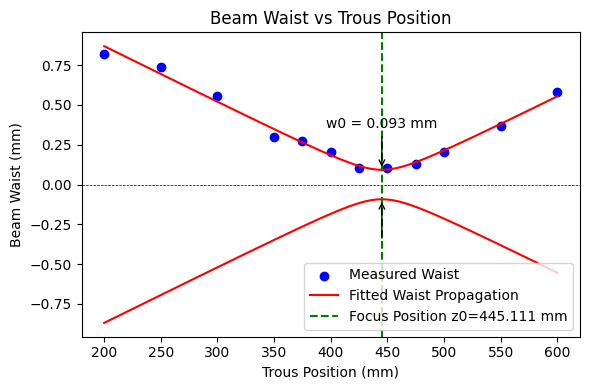

In [67]:
# Plot waist vs trous position
plt.figure(figsize=(6,4))
plt.scatter(d, w, color='blue', label='Measured Waist')
# plot fitted curve
z_fit = np.linspace(min(d), max(d), 500)
w_fit = waist_propagation(z_fit, *params)
plt.plot(z_fit, w_fit, color='red', label='Fitted Waist Propagation')
plt.plot(z_fit, -w_fit, color='red')  # negative waist for symmetry

# Indicate the value of the waist at focus on the plot directly using two arrows pointing toward the center of the beam, vertical lines placed at z0_fit
plt.axvline(z0_fit, color='green', linestyle='--', label=f'Focus Position z0={z0_fit:.3f} mm')
# Place a center dashed black line at w=0
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.annotate(f'w0 = {w0_fit:.3f} mm',
             xy=(z0_fit, w0_fit), xycoords='data',
             xytext=(0, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='black'),
             horizontalalignment='center', color='black')
plt.annotate('',
             xy=(z0_fit, -w0_fit), xycoords='data',
             xytext=(0, -30), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='black'),
             horizontalalignment='center', color='black')


plt.xlabel("Trous Position (mm)")
plt.ylabel("Beam Waist (mm)")
plt.title("Beam Waist vs Trous Position")
plt.legend()
plt.tight_layout()
plt.show()